## Keras ANN model for A_Z Handwritten Dataset

## Imporing Libraries

In [1]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

import seaborn as sns  # Import library for data visualization

from tensorflow import keras # Import Keras from TensorFlow

# Import modules for building the Artificial Neural Network (ANN)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from tensorflow.keras.optimizers import RMSprop # Import the RMSprop optimizer for model training
from sklearn.metrics import classification_report, confusion_matrix # Import evaluation metrics

# Import utility for splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split

## Loading Dataset

In [2]:
data = pd.read_csv("A_Z Handwritten Data.csv") # Loading A–Z Handwritten dataset from the CSV file
x = data.iloc[:,1:].values # Extracting the image pixel values (784 features)
y = data.iloc[:,0].values # Extracting the corresponding alphabet labels (0–25)

## Data Preprocessing

In [3]:
x = x.astype("float32") # Converting the image pixel values to floating-point format
x = x/255.0 # Normalizing the pixel values to the range 0–1

# Splitting the dataset into training and testing sets (80% training, 20% testing)
train_images,test_images,train_labels,test_labels = train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

## One-Hot Encoding the Labels

In [4]:
train_labels = keras.utils.to_categorical(train_labels, 26) # Converting the training labels into one-hot encoded vectors (26 alphabet classes)
test_labels = keras.utils.to_categorical(test_labels, 26) # Converting the testing labels into one-hot encoded vectors (26 alphabet classes)

## Visualizing a Sample Training Image

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0.]


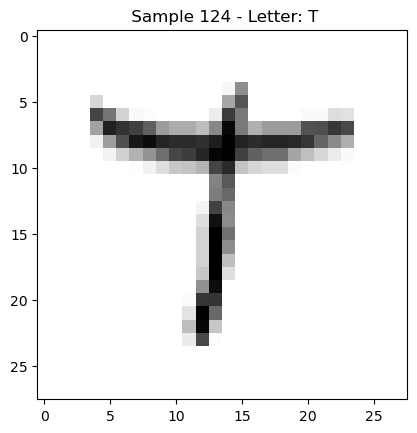

In [5]:
import matplotlib.pyplot as plt

def display_sample(num):
    #Print the one-hot array of this sample's label 
    print(train_labels[num])  
    #Print the label converted back to a number
    label = train_labels[num].argmax(axis=0)
    #Reshape the 784 values to a 28x28 image
    image = train_images[num].reshape([28,28])
    alphabet = chr(label + 65)
    plt.title(f" Sample {num} - Letter: {alphabet}")
    plt.imshow(image, cmap=plt.get_cmap('gray_r'))
    plt.show()
    
display_sample(124) # Display a sample image from the training dataset

## Building the Keras Artificial Neural Network (ANN)

In [6]:
model = Sequential() # Creating a Sequential Artificial Neural Network model
model.add(Dense(512, activation='relu', input_shape=(784,))) # Addimg a fully connected hidden layer with 512 neurons and ReLU activation
model.add(Dropout(0.3)) # Adding a dropout layer to reduce overfitting during training
model.add(Dense(26, activation='softmax')) # Adding the output layer with 26 neurons (one for each alphabet class) and Softmax activation

C:\Users\yarvi\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Model Summary

In [7]:
model.summary() # Display the architecture and trainable parameters of the Keras ANN

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 26)                  │          13,338 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 415,258 (1.58 MB)

 Trainable params: 415,258 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling the Keras ANN Model

In [8]:
# Compile the Keras ANN model by specifying the loss function, optimizer, and evaluation metric
model.compile(loss='categorical_crossentropy', optimizer=RMSprop(), metrics=['accuracy'])

## Training the Keras ANN Model

In [9]:
# Training the Keras ANN model using the training dataset
history = model.fit(train_images, train_labels,
                    batch_size=128,
                    epochs=15,
                    verbose=2,
                    validation_split=0.1)

Epoch 1/15
2096/2096 - 39s - 18ms/step - accuracy: 0.9116 - loss: 0.3217 - val_accuracy: 0.9604 - val_loss: 0.1395
Epoch 2/15
2096/2096 - 38s - 18ms/step - accuracy: 0.9593 - loss: 0.1471 - val_accuracy: 0.9716 - val_loss: 0.1023
Epoch 3/15
2096/2096 - 43s - 20ms/step - accuracy: 0.9668 - loss: 0.1189 - val_accuracy: 0.9737 - val_loss: 0.0937
Epoch 4/15
2096/2096 - 39s - 18ms/step - accuracy: 0.9713 - loss: 0.1040 - val_accuracy: 0.9776 - val_loss: 0.0813
Epoch 5/15
2096/2096 - 31s - 15ms/step - accuracy: 0.9739 - loss: 0.0931 - val_accuracy: 0.9798 - val_loss: 0.0752
Epoch 6/15
2096/2096 - 39s - 19ms/step - accuracy: 0.9761 - loss: 0.0867 - val_accuracy: 0.9811 - val_loss: 0.0704
Epoch 7/15
2096/2096 - 40s - 19ms/step - accuracy: 0.9771 - loss: 0.0813 - val_accuracy: 0.9815 - val_loss: 0.0698
Epoch 8/15
2096/2096 - 21s - 10ms/step - accuracy: 0.9783 - loss: 0.0767 - val_accuracy: 0.9826 - val_loss: 0.0653
Epoch 9/15
2096/2096 - 47s - 22ms/step - accuracy: 0.9795 - loss: 0.0726 - val_a

## Evaluating the Trained Keras ANN Model

In [10]:
score = model.evaluate(test_images, test_labels, verbose=0) # Evaluating the trained model using the testing dataset
print('Test loss:', score[0]) # Display the test loss
print('Test accuracy:', score[1]) # Display the test accuracy

Test loss: 0.06073954701423645
Test accuracy: 0.98585045337677


## Classification Report and Confusion Matrix

2328/2328 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2774
           1       0.98      0.98      0.98      1734
           2       0.98      0.99      0.99      4682
           3       0.98      0.95      0.97      2027
           4       0.99      0.97      0.98      2288
           5       0.96      0.94      0.95       233
           6       0.99      0.97      0.98      1152
           7       0.97      0.96      0.97      1444
           8       0.97      0.96      0.97       224
           9       0.98      0.97      0.98      1699
          10       0.97      0.97      0.97      1121
          11       0.99      0.99      0.99      2317
          12       0.99      0.98      0.99      2467
          13       0.97      0.99      0.98      3802
          14       0.99      1.00      0.99     11565
          15       0.98      0.99      0.99      3868
          16  

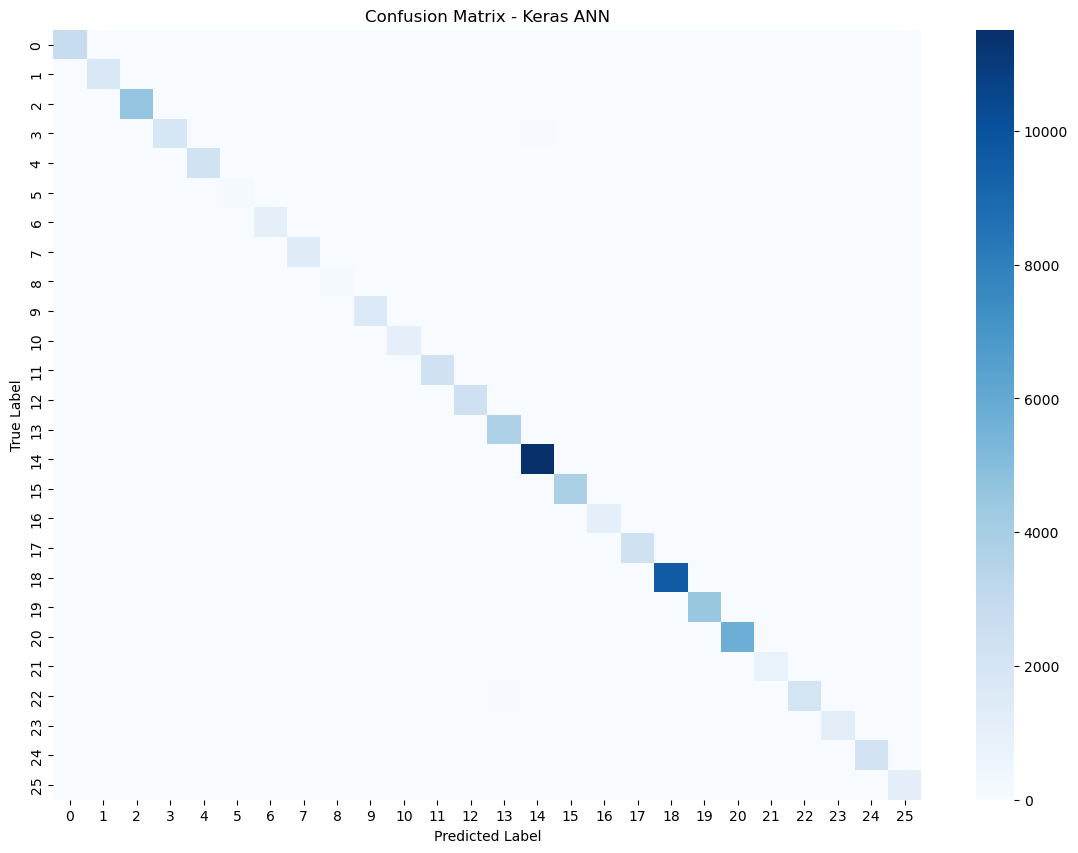

In [11]:
y_pred = model.predict(test_images) # Generate predictions for the testing dataset
y_pred_classes = np.argmax(y_pred, axis=1) # Determine the predicted class for each test image

# Convert one-hot encoded labels back to class numbers
y_true = np.argmax(test_labels, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Display the confusion matrix as a heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix - Keras ANN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Results:
1. Keras ANN has achieved a **test accuracy of approximately 98.55%**, showing excellent performance on the unseen A–Z Handwritten Alphabet test dataset.
2. Classification report shows that this model achieved high **precision, recall, and F1-scores** across almost all alphabet classes. The weighted average scores of **0.99** indicate that the model consistently classified handwritten alphabet images with excellent accuracy.
3. Confusion matrix shows that most predictions lie along the main diagonal, indicating that model has correctly classified most of handwritten alphabet images. Only a few off-diagonal values represent minor misclassifications between visually similar letters, confirming the strong performance.

## Visualizing Sample Model Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


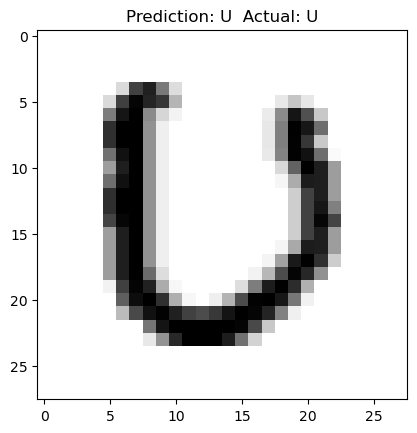

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


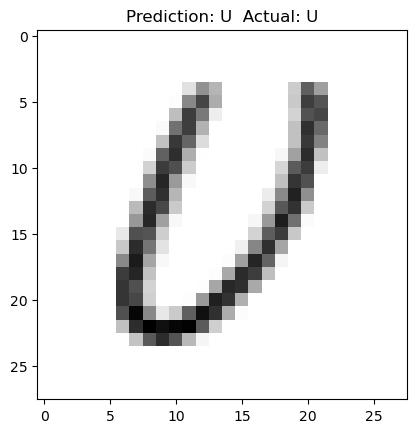

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


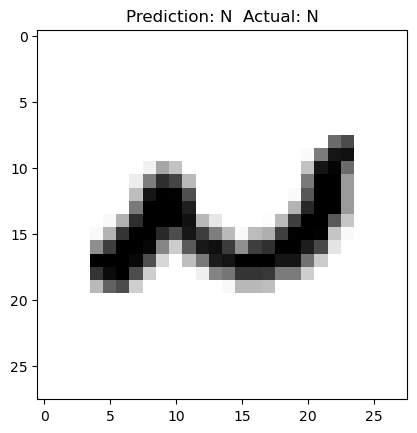

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


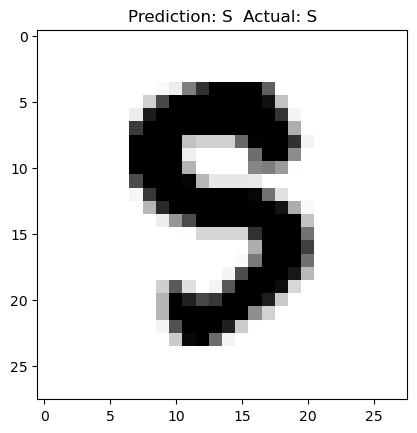

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


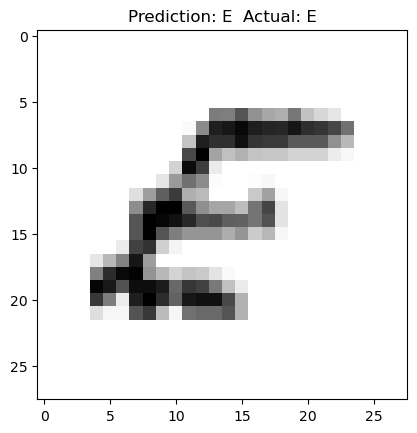

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


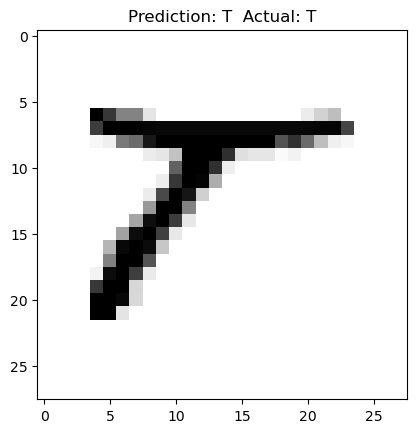

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


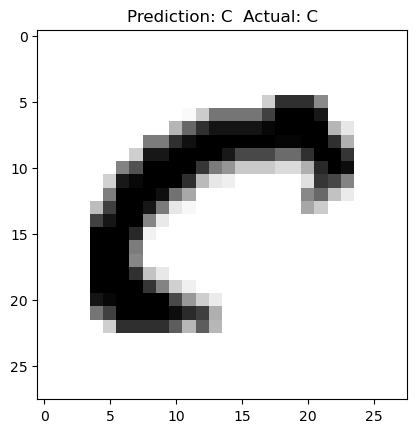

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


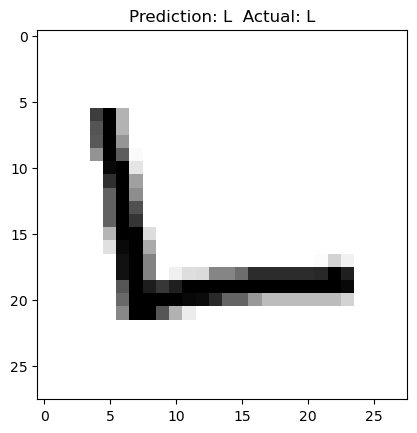

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


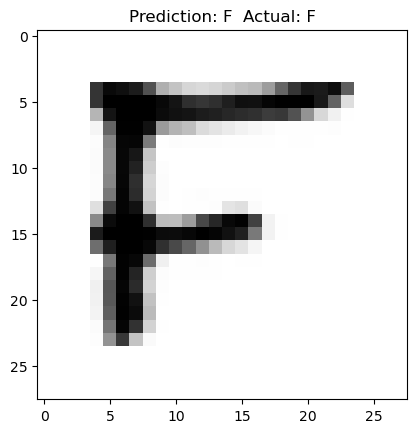

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


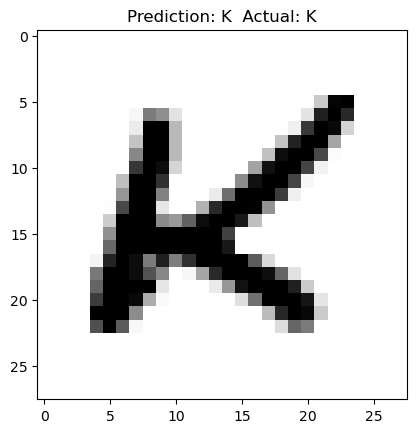

In [12]:
# Display predictions for the first 10 test images
for i in range(10):
    test_image = test_images[i].reshape(1, 784) # Select one test image and reshape it for prediction
    prediction = model.predict(test_image) # Generate the model's prediction
    predicted_cat = prediction.argmax(axis=1)[0] # Convert the predicted probabilities to the predicted class label
    actual_cat = test_labels[i].argmax(axis=0) # Convert the one-hot encoded true label back to its original class label
    
    # Convert the numeric labels to their corresponding alphabet letters
    predicted_letter = chr(predicted_cat + 65) 
    actual_letter = chr(actual_cat + 65)

    # Display the image with its predicted and actual alphabet labels
    plt.title(f"Prediction: {predicted_letter}  Actual: {actual_letter}")
    plt.imshow(test_images[i].reshape(28, 28), cmap='gray_r')
    plt.show()

## Conclusion
The Keras Artificial Neural Network (ANN) successfully classified handwritten alphabet images from the A–Z Handwritten Alphabet dataset with a **test accuracy of approximately 98.55%**. 
The evaluation metrics, classification report, and confusion matrix demonstrate that the model performs consistently across all 26 alphabet classes, making it an effective and reliable approach for handwritten alphabet recognition.